In [47]:
import os
import random
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from Fastkan import FastKAN

In [48]:
number_of_primitives = 3
visible_range = True#Use False to select entire spectrum
include_shadows = True
no_of_epochs = 30
#Visible range of pavia dataset has 66 bands and full spectrum has 103 bands
no_of_bands = 66 if visible_range else 103
output_classes = 9 if include_shadows else 8

In [49]:
hsi = scipy.io.loadmat("PaviaU.mat")
image = hsi["paviaU"]

gt = scipy.io.loadmat("PaviaU_gt.mat")
index = gt["paviaU_gt"]
image  =image[:, :, :no_of_bands]

print(image.shape)
print(index.shape)

(610, 340, 66)
(610, 340)


In [50]:
#Normalizing the image
max_val = np.max(image)
normalized_image = image.astype(np.float32) / max_val

In [51]:

image_for_training = normalized_image[:,:,:no_of_bands]
print(image_for_training.shape)

(610, 340, 66)


In [52]:
x = []
for i in range(len(image_for_training)):
    for j in range(len(image_for_training[0])):
        if (index[i][j] == 0) or (index[i][j] == 9 and (not include_shadows)): #Ignoring all unclassified pixels
            continue
        x.append(image_for_training[i][j])

x = np.asarray(x,dtype=np.float32)
print(x.shape)

(42776, 66)


In [53]:
y = []

for i in range(len(image)):
    for j in range(len(image[0])):
        if index[i][j] == 0 or \
           (index[i][j] == 9 and (not include_shadows)):
            continue

        y.append(index[i][j]-1)

y = np.asarray(y , dtype=np.int64)
y.shape

(42776,)

In [54]:
class ColorFastKAN(nn.Module):

    def __init__( self, no_of_bands,number_of_primitives,output_classes,):
        super().__init__()
        self.primitives = nn.ModuleList([
            FastKAN(
                layers_hidden=[no_of_bands, 1], spectral_response_init=1.0)
            for _ in range(number_of_primitives)
        ])
        self.classifier_dense = nn.Linear(in_features =number_of_primitives , out_features =output_classes )

    def forward(self, x):
        primitive_outputs = [
            primitive(x)
            for primitive in self.primitives]
        merged = torch.cat(primitive_outputs ,dim=1)
        kan_logits = self.classifier_dense(merged)
        return kan_logits

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = ColorFastKAN(no_of_bands=no_of_bands,number_of_primitives=number_of_primitives,output_classes=output_classes).to(device)

Using device: cpu


In [55]:
print(model)


ColorFastKAN(
  (primitives): ModuleList(
    (0-2): 3 x FastKAN(
      (layers): ModuleList(
        (0): Fast_KANLinear(
          (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True)
          (rbf): RadialBasisFunction()
          (spline_linear): SplineLinear(in_features=528, out_features=1, bias=False)
          (base_linear): Linear(in_features=66, out_features=1, bias=True)
        )
      )
    )
  )
  (classifier_dense): Linear(in_features=3, out_features=9, bias=True)
)


In [56]:
def spectral_smoothness_loss(model):

    loss = 0.0
    count = 0

    for primitive in model.primitives:

        for layer in primitive.layers:

            s = torch.nn.functional.softplus(
                layer.spectral_response
            )

            s = s / (
                s.mean() + 1e-8
            )

            # second-order difference
            d2 = (
                s[2:]
                - 2 * s[1:-1]
                + s[:-2]
            )

            loss = loss + d2.pow(2).mean()

            count += 1

    return loss / count

In [57]:
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = model.to(device)

summary(
    model,
    input_size=(1, no_of_bands))

optimizer = torch.optim.Adam(
    model.parameters(),)

criterion = nn.CrossEntropyLoss()
# smoothness strength 
lamda_smooth =1e-1


x_tensor = torch.tensor( x,dtype=torch.float32)

y_tensor = torch.tensor( y,dtype=torch.long)

batch_size = 32

dataset = TensorDataset(x_tensor,y_tensor)

train_loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

loss_history = []
accuracy_history = []

for epoch in range(no_of_epochs):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()

        output = model(batch_x)

        classification_loss = criterion(output,batch_y)
        # spectral smoothness loss
        smooth_loss =spectral_smoothness_loss(model)
        # total loss
        loss =(classification_loss + lamda_smooth*smooth_loss)
        loss.backward()

        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        predictions = torch.argmax(output,dim=1)

        total_correct += ( predictions == batch_y).sum().item()

        total_samples += batch_y.size(0)

    epoch_loss = total_loss / total_samples

    epoch_accuracy = (total_correct / total_samples
    )

    loss_history.append(
        epoch_loss
    )

    accuracy_history.append(
        epoch_accuracy
    )

    print(
        f"Epoch [{epoch+1}/{no_of_epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f} | "
        f"Smooth: {smooth_loss.item():.6f}"
    )

Using device: cpu
Epoch [1/30] | Loss: 1.0303 | Accuracy: 0.6331 | Smooth: 0.007018
Epoch [2/30] | Loss: 0.6442 | Accuracy: 0.7775 | Smooth: 0.005656
Epoch [3/30] | Loss: 0.5922 | Accuracy: 0.7948 | Smooth: 0.006106
Epoch [4/30] | Loss: 0.5642 | Accuracy: 0.8040 | Smooth: 0.006351
Epoch [5/30] | Loss: 0.5454 | Accuracy: 0.8092 | Smooth: 0.006512
Epoch [6/30] | Loss: 0.5315 | Accuracy: 0.8148 | Smooth: 0.006140
Epoch [7/30] | Loss: 0.5215 | Accuracy: 0.8185 | Smooth: 0.005935
Epoch [8/30] | Loss: 0.5137 | Accuracy: 0.8192 | Smooth: 0.005489
Epoch [9/30] | Loss: 0.5073 | Accuracy: 0.8222 | Smooth: 0.005088
Epoch [10/30] | Loss: 0.5016 | Accuracy: 0.8233 | Smooth: 0.004789
Epoch [11/30] | Loss: 0.4979 | Accuracy: 0.8257 | Smooth: 0.004550
Epoch [12/30] | Loss: 0.4941 | Accuracy: 0.8264 | Smooth: 0.004353
Epoch [13/30] | Loss: 0.4891 | Accuracy: 0.8276 | Smooth: 0.004113
Epoch [14/30] | Loss: 0.4870 | Accuracy: 0.8290 | Smooth: 0.003901
Epoch [15/30] | Loss: 0.4842 | Accuracy: 0.8303 | Smo

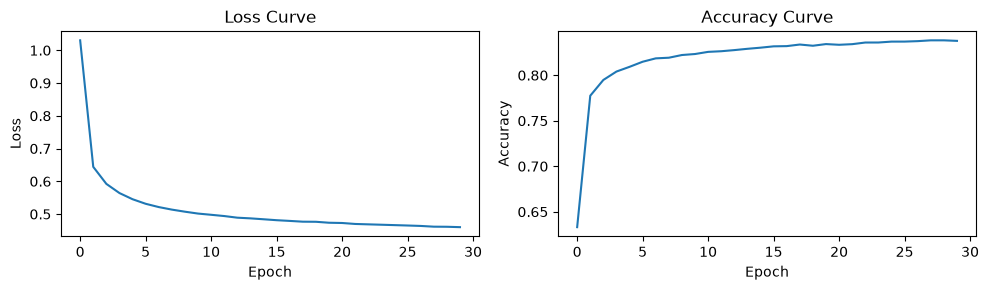

In [58]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [59]:
wavelength = np.linspace(430, 860, no_of_bands) #430 - 860 is range of paviaU dataset and 103 is number of bands
wavelength_int = wavelength.astype(int)
print(wavelength_int)

[430 436 443 449 456 463 469 476 482 489 496 502 509 516 522 529 535 542
 549 555 562 568 575 582 588 595 602 608 615 621 628 635 641 648 654 661
 668 674 681 688 694 701 707 714 721 727 734 740 747 754 760 767 774 780
 787 793 800 807 813 820 826 833 840 846 853 860]


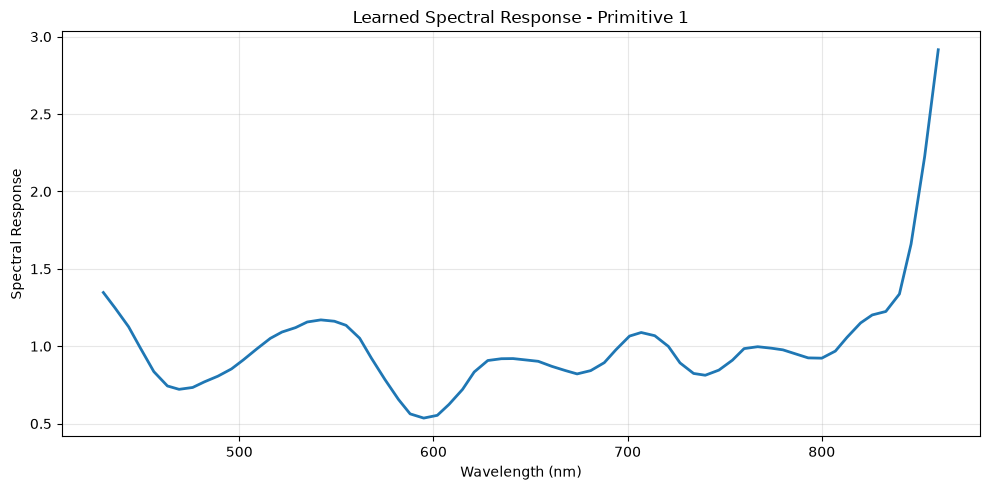

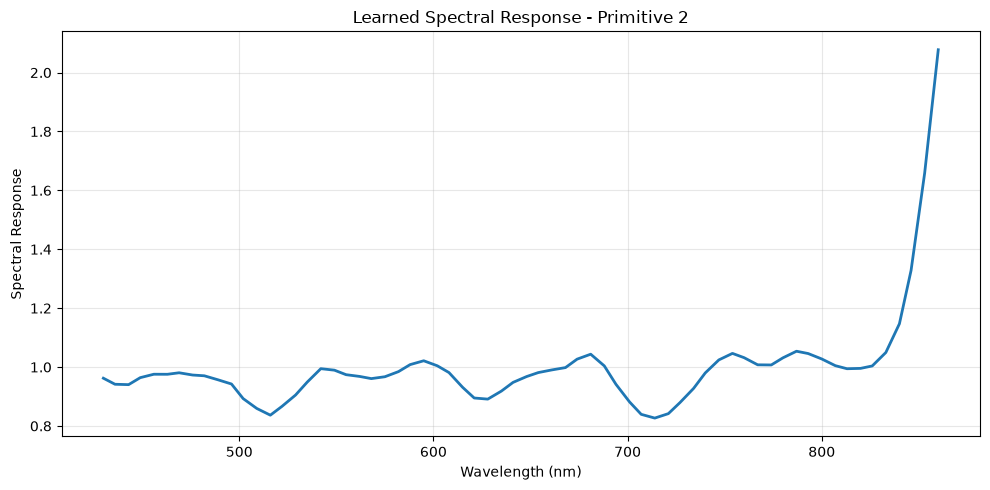

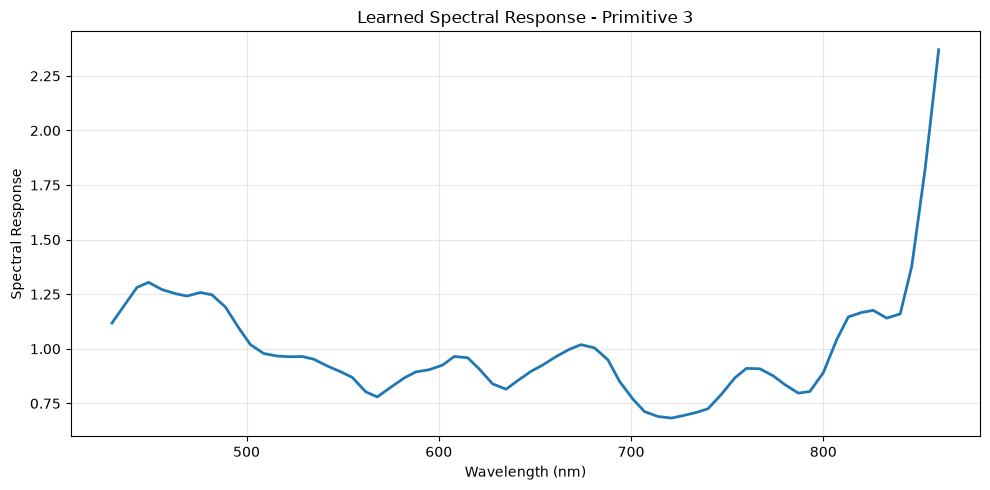

In [60]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

model.eval()

primitive_curves = []

for primitive_no in range(number_of_primitives):

    # First/only layer of this primitive
    layer = model.primitives[primitive_no].layers[0]

    with torch.no_grad():

        # Learned spectral response
        spectral_response = F.softplus(
            layer.spectral_response
        )

        # Normalize mean response to 1
        spectral_response = (
            spectral_response /
            (spectral_response.mean() + 1e-8)
        )

    curve = spectral_response.cpu().numpy()

    primitive_curves.append(curve)

# -----------------------------------------
# Plot individual primitive curves
# -----------------------------------------

for primitive_no, curve in enumerate(primitive_curves):

    plt.figure(figsize=(10, 5))

    plt.plot(
        wavelength_int[:no_of_bands],
        curve,
        linewidth=2
    )

    plt.title(
        f"Learned Spectral Response - Primitive {primitive_no + 1}"
    )

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Spectral Response")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [61]:
for i ,p in enumerate(primitive_curves):
    print(i+1, f"primitive_{i+1}" , p[0])



1 primitive_1 1.3470626
2 primitive_2 0.9622677
3 primitive_3 1.1180451


In [62]:
for i, (name, parameter) in enumerate(model.named_parameters()):
    if parameter.requires_grad:
        print(i, name, parameter.shape)

0 primitives.0.layers.0.spectral_response torch.Size([66])
1 primitives.0.layers.0.layernorm.weight torch.Size([66])
2 primitives.0.layers.0.layernorm.bias torch.Size([66])
3 primitives.0.layers.0.spline_linear.weight torch.Size([1, 528])
4 primitives.0.layers.0.base_linear.weight torch.Size([1, 66])
5 primitives.0.layers.0.base_linear.bias torch.Size([1])
6 primitives.1.layers.0.spectral_response torch.Size([66])
7 primitives.1.layers.0.layernorm.weight torch.Size([66])
8 primitives.1.layers.0.layernorm.bias torch.Size([66])
9 primitives.1.layers.0.spline_linear.weight torch.Size([1, 528])
10 primitives.1.layers.0.base_linear.weight torch.Size([1, 66])
11 primitives.1.layers.0.base_linear.bias torch.Size([1])
12 primitives.2.layers.0.spectral_response torch.Size([66])
13 primitives.2.layers.0.layernorm.weight torch.Size([66])
14 primitives.2.layers.0.layernorm.bias torch.Size([66])
15 primitives.2.layers.0.spline_linear.weight torch.Size([1, 528])
16 primitives.2.layers.0.base_linear.

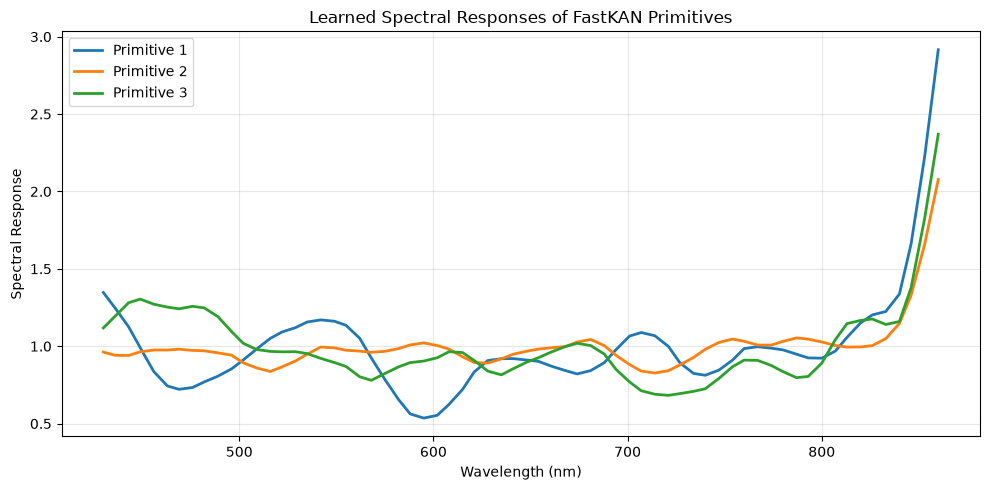

In [63]:
plt.figure(figsize=(10, 5))

for primitive_no, curve in enumerate(primitive_curves):

    plt.plot(
        wavelength_int[:no_of_bands],
        curve,
        linewidth=2,
        label=f"Primitive {primitive_no + 1}"
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral Response")
plt.title("Learned Spectral Responses of FastKAN Primitives")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
model_name = (
    f'{no_of_bands}bands_'f'{number_of_primitives}primitives_' f'{"with_shadow" if include_shadows else "without_shadow"}_' f'fastkan_random_init')
print(model_name)

66bands_3primitives_with_shadow_fastkan_random_init


In [65]:
print(model_name)

66bands_3primitives_with_shadow_fastkan_random_init


In [66]:
torch.save(model.state_dict(), f"{model_name}.pth")

In [67]:
model = ColorFastKAN(
    no_of_bands,
    number_of_primitives,
    output_classes
)

model.load_state_dict(torch.load(f"{model_name}.pth"))
model.eval()

ColorFastKAN(
  (primitives): ModuleList(
    (0-2): 3 x FastKAN(
      (layers): ModuleList(
        (0): Fast_KANLinear(
          (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True)
          (rbf): RadialBasisFunction()
          (spline_linear): SplineLinear(in_features=528, out_features=1, bias=False)
          (base_linear): Linear(in_features=66, out_features=1, bias=True)
        )
      )
    )
  )
  (classifier_dense): Linear(in_features=3, out_features=9, bias=True)
)

In [68]:
def predict_image():
    x_pred = image_for_training.reshape(-1, no_of_bands)

    print("Prediction Input Shape:", x_pred.shape)
    print("Predicting...")

    x_pred = torch.tensor( x_pred,dtype=torch.float32, device=device)

    model.eval()

    with torch.no_grad():

        primitive_outputs = [primtive(x_pred) for primtive in model.primitives]
        prediction = torch.cat(primitive_outputs,dim=1)

    predicted_image = prediction.cpu().numpy().reshape(
        image.shape[0],
        image.shape[1],
        number_of_primitives
    )

    return predicted_image
def normalize_images(predicted_image, channels):

    max_val = np.max(predicted_image)

    if max_val == 0:
        global_max_image = predicted_image.copy()
    else:
        global_max_image = predicted_image / max_val

    signed_channelwise_image = np.zeros_like(predicted_image , dtype=np.float32)

    for i in range(predicted_image.shape[-1]):

        channel = predicted_image[:, :, i]

        channel_max = np.max(np.abs(channel))

        if channel_max!= 0:
            signed_channelwise_image[:, :, i] = (
                channel / channel_max
            )
        else:
            signed_channelwise_image[:, :, i] = channel
    clipped_image = np.clip(
        predicted_image,0,1)
    channel_minmax_image = np.zeros_like(predicted_image , dtype=np.float32)
    for i in range(predicted_image.shape[-1]):
        channel = predicted_image[: , : , i]
        channel_min = np.min(channel)
        channel_max = np.max(channel)
        channel_minmax_image[: ,: ,i] = (channel -channel_min)/(channel_max -channel_min + 1e-8)
    c1 , c2 , c3 = [channel -1 for channel in channels]

    rgb_global_max = np.dstack((
        global_max_image[:, :, c1],
        global_max_image[:, :, c2],
        global_max_image[:, :, c3]
    ))

    rgb_signed_channelwise = np.dstack((
        signed_channelwise_image[:, :, c1],
        signed_channelwise_image[:, :, c2],
        signed_channelwise_image[:, :, c3]
    ))

    rgb_clipped = np.dstack((
        clipped_image[:, :, c1],
        clipped_image[:, :, c2],
        clipped_image[:, :, c3]
    ))
   
    return [
        rgb_global_max ,
        rgb_signed_channelwise,
        rgb_clipped
    ]

Prediction Input Shape: (207400, 66)
Predicting...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.61421376..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8190292..1.0].


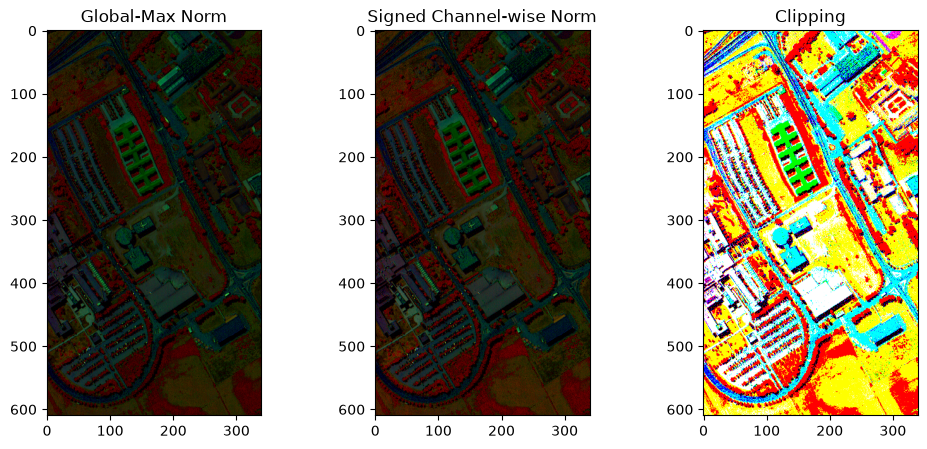

In [69]:
channels = [1, 2, 3]

predicted_image = predict_image()

normalized_images = normalize_images(
    predicted_image,
    channels
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(normalized_images[0])
plt.title("Global-Max Norm")

plt.subplot(1, 3, 2)
plt.imshow(normalized_images[1])
plt.title("Signed Channel-wise Norm")

plt.subplot(1, 3, 3)
plt.imshow(normalized_images[2])
plt.title("Clipping")

plt.show()